In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/Country-data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (167, 10)

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Null Values:
coun

## Section 1 - Setup & Data Loading

We begin by importing the required libraries and loading the dataset. A basic inspection is performed to understand the structure, data types, missing values, and duplicates.

**Observations:**
- The dataset contains 167 countries and 10 columns.
- 1 categorical column: `country` (will be dropped before modeling).
- 8 numerical features representing socioeconomic indicators.
- No null values and no duplicate rows dataset is clean and ready for analysis.

## Section 2 - Exploratory Data Analysis (EDA)

In this section we visually explore the distribution of each feature, check for skewness, detect outliers, and understand relationships between variables.

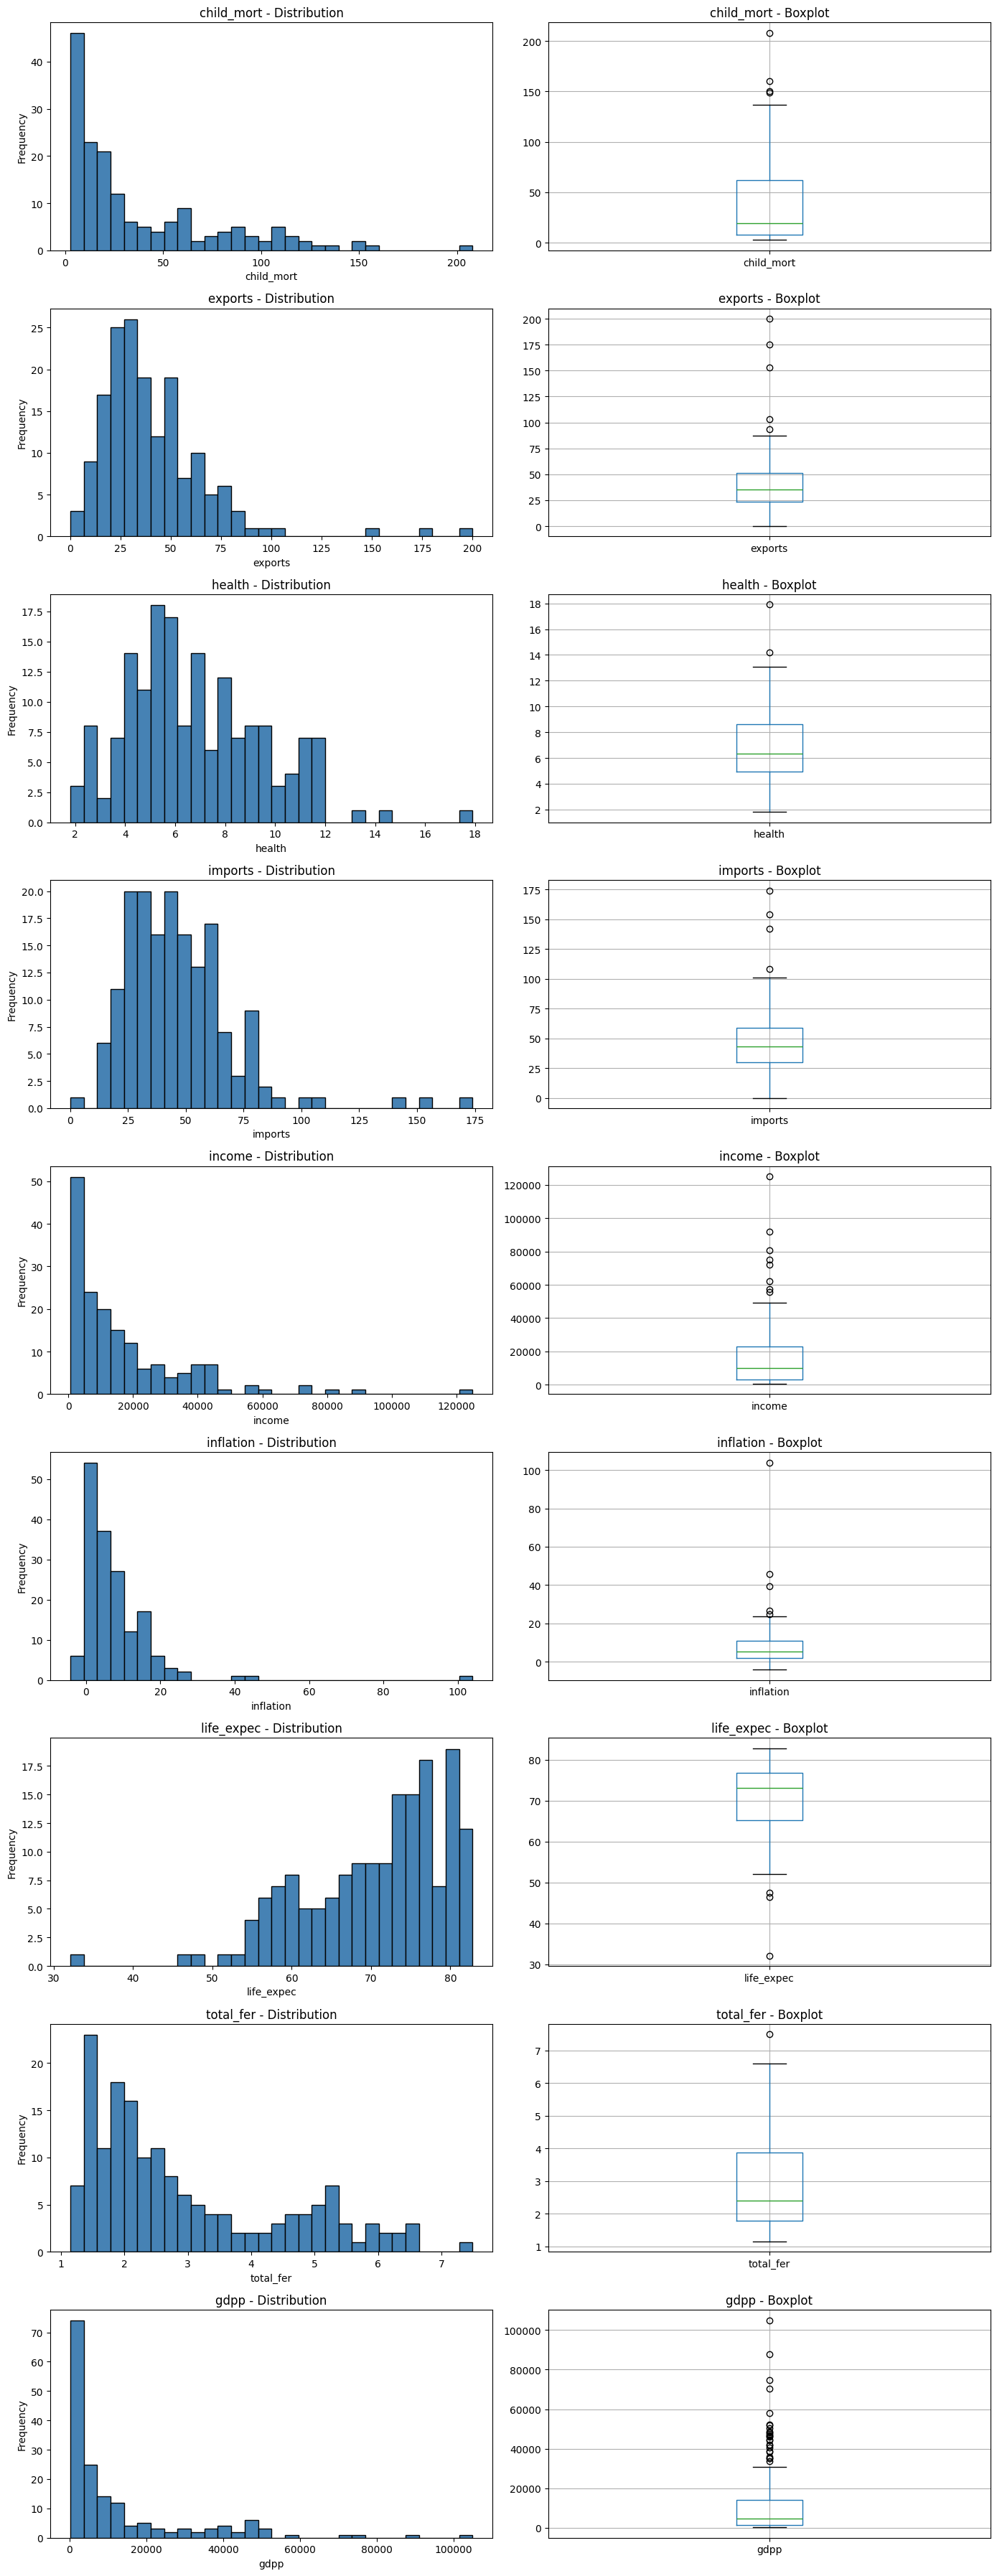

In [28]:
features = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))

for i, col in enumerate(features):
    df[col].plot(kind='hist', bins=30, ax=axes[i][0], color='steelblue', edgecolor='black')
    axes[i][0].set_title(f'{col} - Distribution')
    axes[i][0].set_xlabel(col)

    df.boxplot(column=col, ax=axes[i][1])
    axes[i][1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

**Observations:**

- `child_mort`: heavily right-skewed with several high outliers. Most countries have low child mortality but a few have extremely high values.
- `exports` and `imports`: right-skewed with a few countries having very high trade volumes as outliers.
- `health`: relatively more normally distributed compared to other features, mild right skew.
- `income`: strongly right-skewed. A small number of very high-income countries pull the distribution far right.
- `inflation`: strongly right-skewed with extreme outliers. One country has inflation close to 100.
- `life_expec`: left-skewed. Most countries have high life expectancy, with a few low-performing outliers.
- `total_fer`: right-skewed. Most countries have low fertility rates but some have values close to 7.5.
- `gdpp`: strongly right-skewed with extreme outliers. Wealth is concentrated in very few countries.

Features like `child_mort`, `income`, `gdpp`, and `inflation` will need log transformation in the feature engineering step to handle skewness before modeling.

In [29]:
skew_kurt = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurt()
}).round(2)

print(skew_kurt)

            Skewness  Kurtosis
child_mort      1.45      1.77
exports         2.45     10.14
health          0.71      0.69
imports         1.91      6.76
income          2.23      7.03
inflation       5.15     41.74
life_expec     -0.97      1.15
total_fer       0.97     -0.19
gdpp            2.22      5.53


**Observations:**

- Skewness above 1 or below -1 is considered highly skewed. Features like `inflation` (5.15), `exports` (2.45), `income` (2.23), `gdpp` (2.22), and `imports` (1.91) are all highly right-skewed.
- `child_mort` (1.45) and `total_fer` (0.97) are moderately skewed.
- `life_expec` (-0.97) is moderately left-skewed, meaning most countries have high life expectancy.
- `health` (0.71) is the most normally distributed feature.
- Kurtosis above 3 indicates heavy tails with extreme outliers. `inflation` (41.74), `exports` (10.14), `imports` (6.76), `income` (7.03), and `gdpp` (5.53) all have heavy tails confirming the outliers we saw in the boxplots.

These results confirm that log transformation is needed on `child_mort`, `exports`, `imports`, `income`, `inflation`, and `gdpp` before modeling.

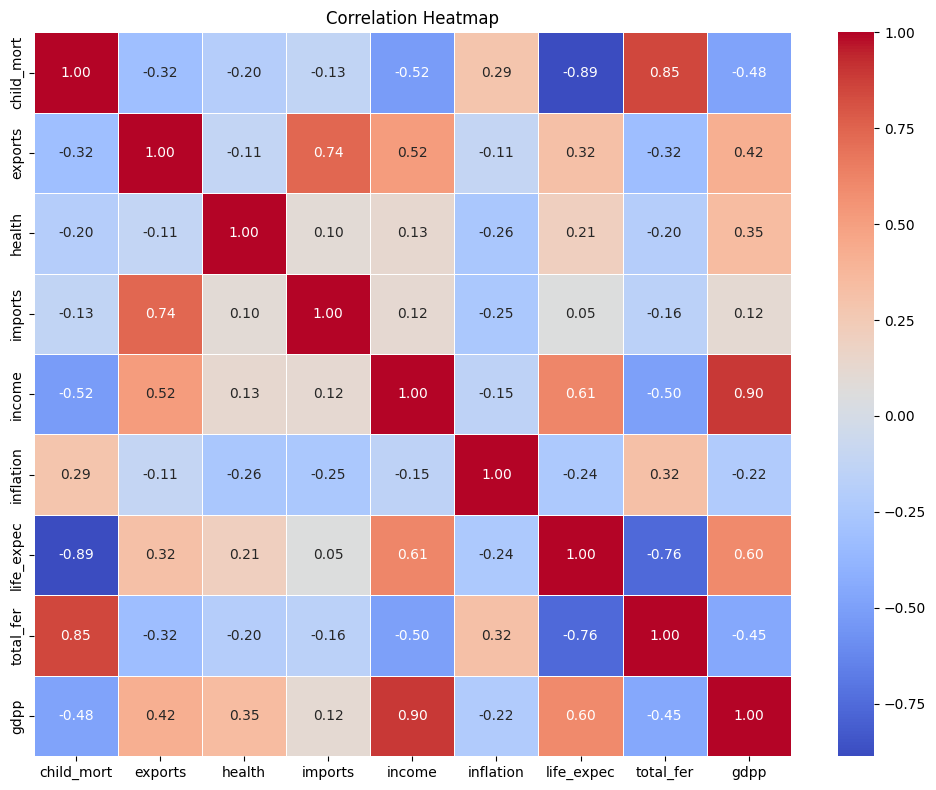

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:**

- `child_mort` and `life_expec` have a strong negative correlation (-0.89). Countries with high child mortality tend to have low life expectancy.
- `child_mort` and `total_fer` have a strong positive correlation (0.85). High fertility rates are associated with high child mortality.
- `income` and `gdpp` have a very strong positive correlation (0.90). Wealthier countries have higher per capita income as expected.
- `life_expec` and `total_fer` have a strong negative correlation (-0.76). Countries with high life expectancy tend to have lower fertility rates.
- `life_expec` and `income` have a moderate positive correlation (0.61). Higher income countries tend to have better life expectancy.
- `exports` and `imports` have a strong positive correlation (0.74). Countries that trade more tend to both export and import heavily.
- `inflation` has weak correlations with most features, suggesting it behaves more independently.

These correlations confirm that `child_mort`, `life_expec`, `total_fer`, `income`, and `gdpp` are the most informative features for separating countries into distinct groups.

In [31]:
outlier_summary = {}

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print(outlier_df)

            Outlier Count
child_mort              4
exports                 5
health                  2
imports                 4
income                  8
inflation               5
life_expec              3
total_fer               1
gdpp                   25


**Observations:**

- `gdpp` has the highest number of outliers (25), confirming that global wealth is highly concentrated in a few countries.
- `inflation` (5) and `exports` (5) also have notable outliers, indicating a few economies with extreme trade or inflation behavior.
- `income` (8) has several outliers consistent with the strong right skew we observed earlier.
- `child_mort` (4) and `imports` (4) have a moderate number of outliers.
- `life_expec` (3) and `health` (2) have fewer outliers, suggesting more uniform distributions.
- `total_fer` has only 1 outlier.

We will not remove these outliers as they represent real country-level differences that are meaningful for clustering. Log transformation in the feature engineering step will reduce their impact on the model.

In [32]:
stats = df[features].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
stats.loc['range'] = stats.loc['max'] - stats.loc['min']
stats.loc['cv'] = (stats.loc['std'] / stats.loc['mean'] * 100).round(2)

print(stats)

        child_mort  exports  health  imports     income  inflation  \
mean         38.27    41.11    6.82    46.89   17144.69       7.78   
median       19.30    35.00    6.32    43.30    9960.00       5.39   
std          40.33    27.41    2.75    24.21   19278.07      10.57   
min           2.60     0.11    1.81     0.07     609.00      -4.21   
max         208.00   200.00   17.90   174.00  125000.00     104.00   
range       205.40   199.89   16.09   173.93  124391.00     108.21   
cv          105.38    66.67   40.32    51.63     112.44     135.86   

        life_expec  total_fer       gdpp  
mean         70.56       2.95   12964.16  
median       73.10       2.41    4660.00  
std           8.89       1.51   18328.70  
min          32.10       1.15     231.00  
max          82.80       7.49  105000.00  
range        50.70       6.34  104769.00  
cv           12.60      51.19     141.38  


**Observations:**

- `gdpp` has the highest coefficient of variation (CV) at 141.38%, meaning it has the most relative spread across countries. `inflation` (135.86%) and `income` (112.44%) also show extremely high variability.
- `child_mort` has a mean of 38.27 but a median of 19.30, confirming strong right skew. The majority of countries have low child mortality but a few extreme cases push the mean up significantly.
- `gdpp` has a massive range of 104,769 with min 231 and max 105,000, confirming the huge economic inequality between countries.
- `income` similarly ranges from 609 to 125,000, a difference of over 200x between the poorest and richest countries.
- `life_expec` has the lowest CV (12.60%), meaning it is the most consistent feature across countries relative to its mean.
- `health` also has a low CV (40.32%) compared to economic features, suggesting health spending as a percentage of GDP is more uniformly distributed.
- The large gap between mean and median in `gdpp`, `income`, and `child_mort` confirms these features are dominated by a small number of extreme countries.

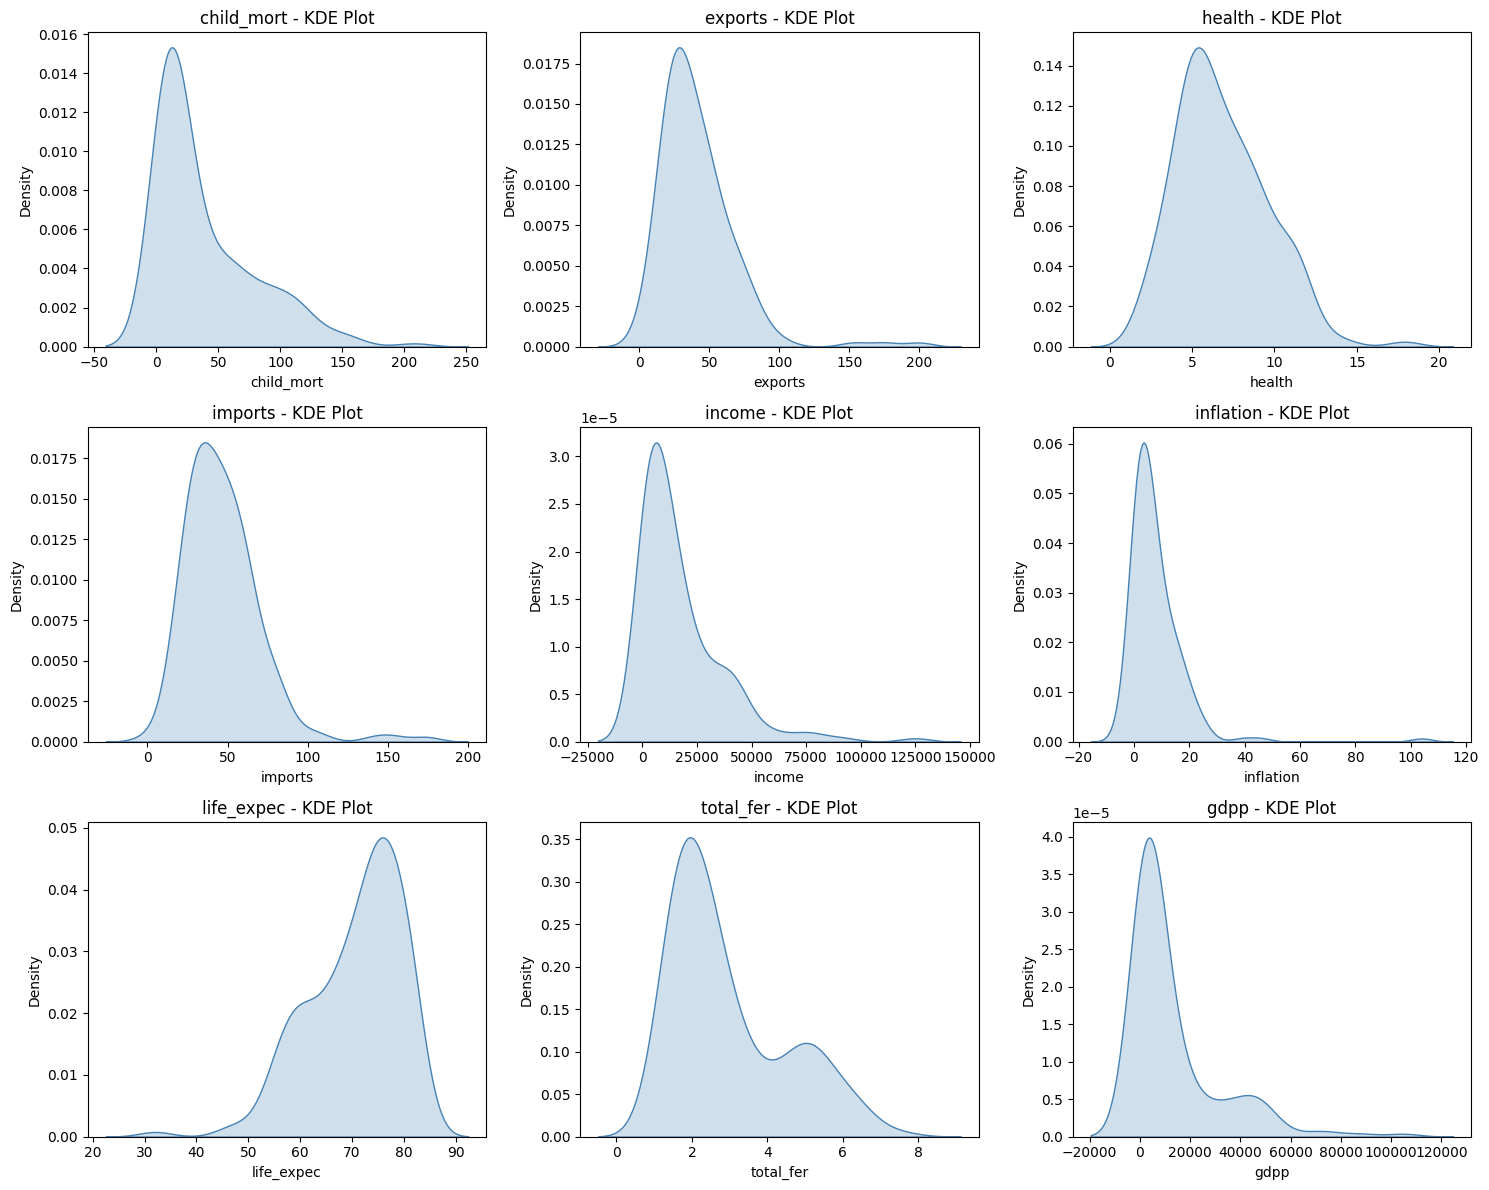

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(df[col], ax=axes[i], fill=True, color='steelblue')
    axes[i].set_title(f'{col} - KDE Plot')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Observations:**

- `child_mort`, `exports`, `imports`, `income`, `inflation`, and `gdpp` all show a sharp peak near zero with a long right tail, confirming strong right skew and non-normal distribution.
- `life_expec` shows a left-skewed distribution with most values concentrated between 65 and 80, indicating most countries have reasonably high life expectancy.
- `total_fer` shows a bimodal distribution with two peaks, one around 2 and another around 5, suggesting two distinct groups of countries with very different fertility behaviors.
- `health` is the closest to a normal distribution among all features, with a relatively symmetric bell shape.
- None of the features follow a perfect normal distribution, confirming the need for log transformation on the heavily skewed ones before feeding data into the model.

## Section 4 - Feature Engineering

In this section we create new meaningful features from existing ones to capture deeper relationships in the data. We also apply log transformation on heavily skewed features to reduce the effect of extreme values on the model.

In [34]:
df_eng = df.copy()

# new features
df_eng['health_gdp_ratio'] = (df_eng['health'] / df_eng['gdpp']) * 1000
df_eng['trade_balance'] = df_eng['exports'] - df_eng['imports']
df_eng['mortality_fertility_index'] = df_eng['child_mort'] * df_eng['total_fer']
df_eng['health_spend_abs'] = (df_eng['health'] / 100) * df_eng['gdpp']

# log transformations
df_eng['log_child_mort'] = np.log1p(df_eng['child_mort'])
df_eng['log_income'] = np.log1p(df_eng['income'])
df_eng['log_gdpp'] = np.log1p(df_eng['gdpp'])
df_eng['log_inflation'] = np.log1p(df_eng['inflation'].clip(lower=0))

print(df_eng.shape)
print(df_eng.head())

(167, 18)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  health_gdp_ratio  trade_balance  \
0       9.44        56.2       5.82    553         13.707052          -34.9   
1       4.49        76.3       1.65   4090          1.601467          -20.6   
2      16.10        76.5       2.89   4460          0.934978            7.0   
3      22.40        60.1       6.16   3530          0.807365           19.4   
4       1.44        76.8       2.13  12200          0.494262          -13.4   

   mortality_fertility_index  health_spend_abs  log_child_mort  log_income  \
0   

**New features created:**

- `health_gdp_ratio`: health spending relative to GDP per capita, scaled by 1000. Captures how much a country invests in health relative to its wealth.
- `trade_balance`: exports minus imports. A positive value means the country exports more than it imports, negative means trade deficit.
- `mortality_fertility_index`: child mortality multiplied by fertility rate. A combined index that captures overall population health stress.
- `log_child_mort`: log transformation of child mortality to reduce right skew.
- `log_income`: log transformation of income to reduce right skew.
- `log_gdpp`: log transformation of GDP per capita to reduce right skew.
- `log_inflation`: log transformation of inflation after clipping negative values to 0.

The dataframe now has 17 columns, up from the original 10.

## Section 5 - Preprocessing

In this section we prepare the data for modeling. We drop the `country` column as it is non-numeric, select the final feature set, and apply StandardScaler to bring all features to the same scale before clustering.

In [35]:
from sklearn.preprocessing import StandardScaler

cols_to_drop = ['country', 'child_mort', 'income', 'gdpp', 'inflation']
X = df_eng.drop(columns=cols_to_drop)

print("Features used for modeling:")
print(X.columns.tolist())
print("\nShape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaled data sample:")
print(X_scaled.head())

Features used for modeling:
['exports', 'health', 'imports', 'life_expec', 'total_fer', 'health_gdp_ratio', 'trade_balance', 'mortality_fertility_index', 'health_spend_abs', 'log_child_mort', 'log_income', 'log_gdpp', 'log_inflation']

Shape: (167, 13)

Scaled data sample:
    exports    health   imports  life_expec  total_fer  health_gdp_ratio  \
0 -1.138280  0.279088 -0.082455   -1.619092   1.902882          1.575556   
1 -0.479658 -0.097016  0.070837    0.647866  -0.859973         -0.303671   
2 -0.099122 -0.966073 -0.641762    0.670423  -0.038404         -0.407135   
3  0.775381 -1.448071 -0.165315   -1.179234   2.128151         -0.426945   
4  0.160668 -0.286894  0.497568    0.704258  -0.541946         -0.475550   

   trade_balance  mortality_fertility_index  health_spend_abs  log_child_mort  \
0      -1.541835                   1.573693         -0.565040        1.278012   
1      -0.784652                  -0.597441         -0.439218       -0.239708   
2       0.676765          

**Steps performed:**

- Dropped `country` as it is a non-numeric identifier.
- Dropped original skewed columns `child_mort`, `income`, `gdpp`, and `inflation` since their log-transformed versions are already in the dataset.
- Final feature set has 13 columns ready for modeling.
- StandardScaler applied to bring all features to the same scale with mean 0 and standard deviation 1.
- Scaling is important here because K-Means uses Euclidean distance and features with larger ranges would otherwise dominate the clustering.

## Section 6 - K-Means Clustering

We use the Elbow Method and Silhouette Score to find the optimal number of clusters, then fit the final K-Means model and assign cluster labels to each country.

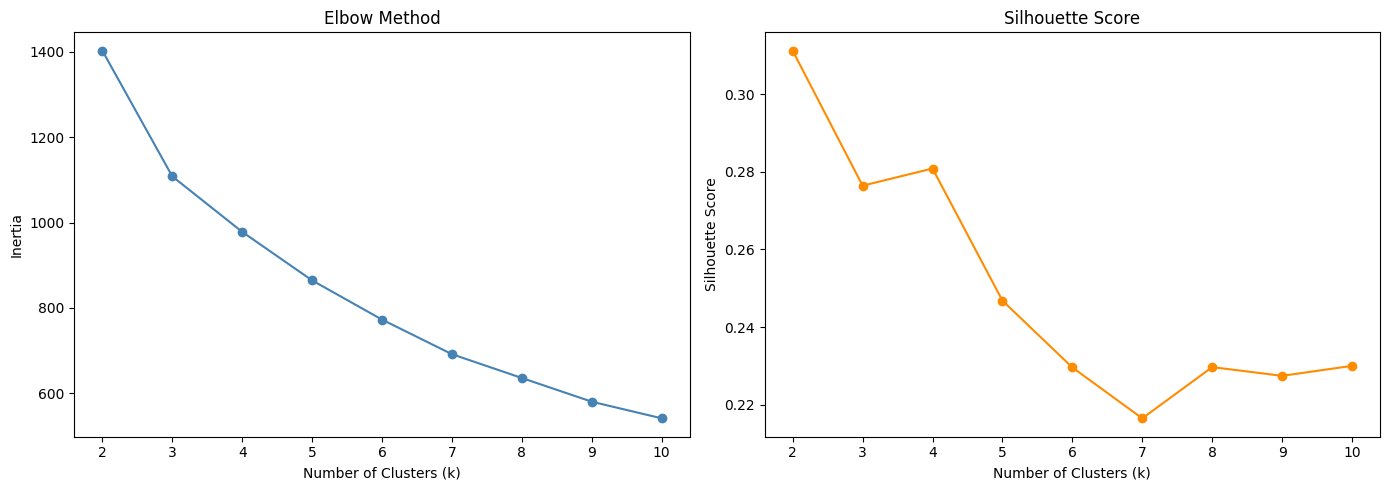

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**Observations:**

- The elbow method shows a clear bend at k=3, after which the rate of inertia reduction slows down significantly.
- The silhouette score is highest at k=2 but drops at k=3 and then partially recovers at k=4.
- k=3 is selected as the optimal number of clusters as it balances cluster quality with meaningful separation of countries into distinct groups.

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_eng['cluster'] = kmeans.labels_

print("Cluster counts:")
print(df_eng['cluster'].value_counts())

Cluster counts:
cluster
1    86
0    44
2    37
Name: count, dtype: int64


**Results:**

- Cluster 1: 86 countries - the largest group
- Cluster 0: 44 countries
- Cluster 2: 37 countries - the smallest group

The clusters are reasonably sized with no extremely small or dominant group, suggesting K-Means has found meaningful separations in the data.

## Section 7 - Cluster Analysis and Visualization

In this section we visualize the clusters using PCA, analyze the mean values of each cluster, and interpret what each cluster represents.

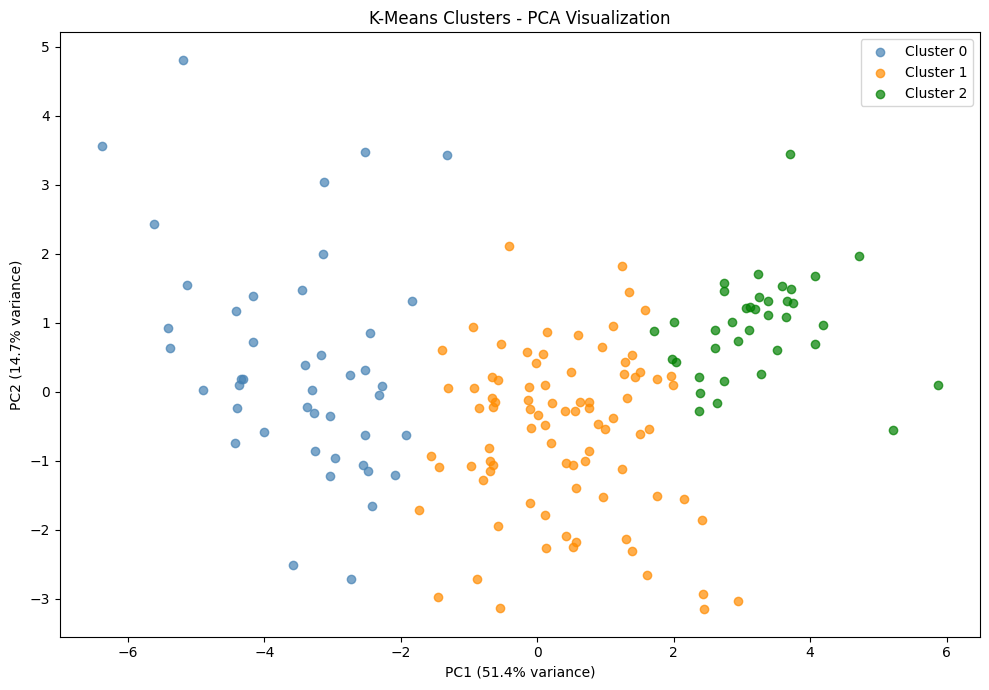

Total variance explained by 2 components: 66.1%


In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df_eng['cluster'].values

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green']
for cluster in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', color=colors[cluster], alpha=0.7)

plt.title('K-Means Clusters - PCA Visualization')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

**Observations:**

- The 2 PCA components explain 66.1% of the total variance in the data, giving a reasonable 2D representation of the clusters.
- Cluster 2 (green) is clearly separated on the right side of PC1, suggesting these countries have distinctly different socioeconomic characteristics from the other two groups.
- Cluster 0 (blue) is spread on the left side of PC1, forming a distinct group as well.
- Cluster 1 (orange) sits in the middle, with some overlap with both Cluster 0 and Cluster 2.
- The separation along PC1 (51.4% variance) is the dominant factor driving cluster differences, meaning the primary socioeconomic differences between countries are captured in this axis.

In [39]:
cluster_means = df_eng.groupby('cluster')[features].mean().round(2)
print(cluster_means)

         child_mort  exports  health  imports    income  inflation  \
cluster                                                              
0             93.16    24.53    6.62    44.10   2130.98      11.49   
1             24.51    42.93    5.84    45.38  16082.56       8.71   
2              4.98    56.59    9.32    53.72  37467.57       1.23   

         life_expec  total_fer      gdpp  
cluster                                   
0             59.67       5.03    998.23  
1             72.21       2.42   8076.65  
2             79.67       1.69  38554.05  


**Cluster Analysis:**

- Cluster 0: highest child mortality (93.16), lowest income (2130), lowest gdpp (998), lowest life expectancy (59.67), and highest fertility rate (5.03). These countries are in the most critical condition and need immediate aid.
- Cluster 1: moderate values across all features. Child mortality at 24.51, income at 16082, life expectancy at 72.21. These countries are developing but not in crisis.
- Cluster 2: lowest child mortality (4.98), highest income (37467), highest gdpp (38554), highest life expectancy (79.67), and lowest fertility rate (1.69). These are the most prosperous countries with the least need for aid.

**Cluster Labels:**
- Cluster 0 - High Need
- Cluster 1 - Moderate Need
- Cluster 2 - Low Need

In [40]:
cluster_labels = {0: 'High Need', 1: 'Moderate Need', 2: 'Low Need'}
df_eng['cluster_label'] = df_eng['cluster'].map(cluster_labels)

print(df_eng[['country', 'cluster', 'cluster_label']].head(10))

               country  cluster  cluster_label
0          Afghanistan        0      High Need
1              Albania        1  Moderate Need
2              Algeria        1  Moderate Need
3               Angola        0      High Need
4  Antigua and Barbuda        1  Moderate Need
5            Argentina        1  Moderate Need
6              Armenia        1  Moderate Need
7            Australia        2       Low Need
8              Austria        2       Low Need
9           Azerbaijan        1  Moderate Need


Cluster labels are assigned to each country based on the mean values analysis. The labels reflect the relative socioeconomic condition of countries within each group.

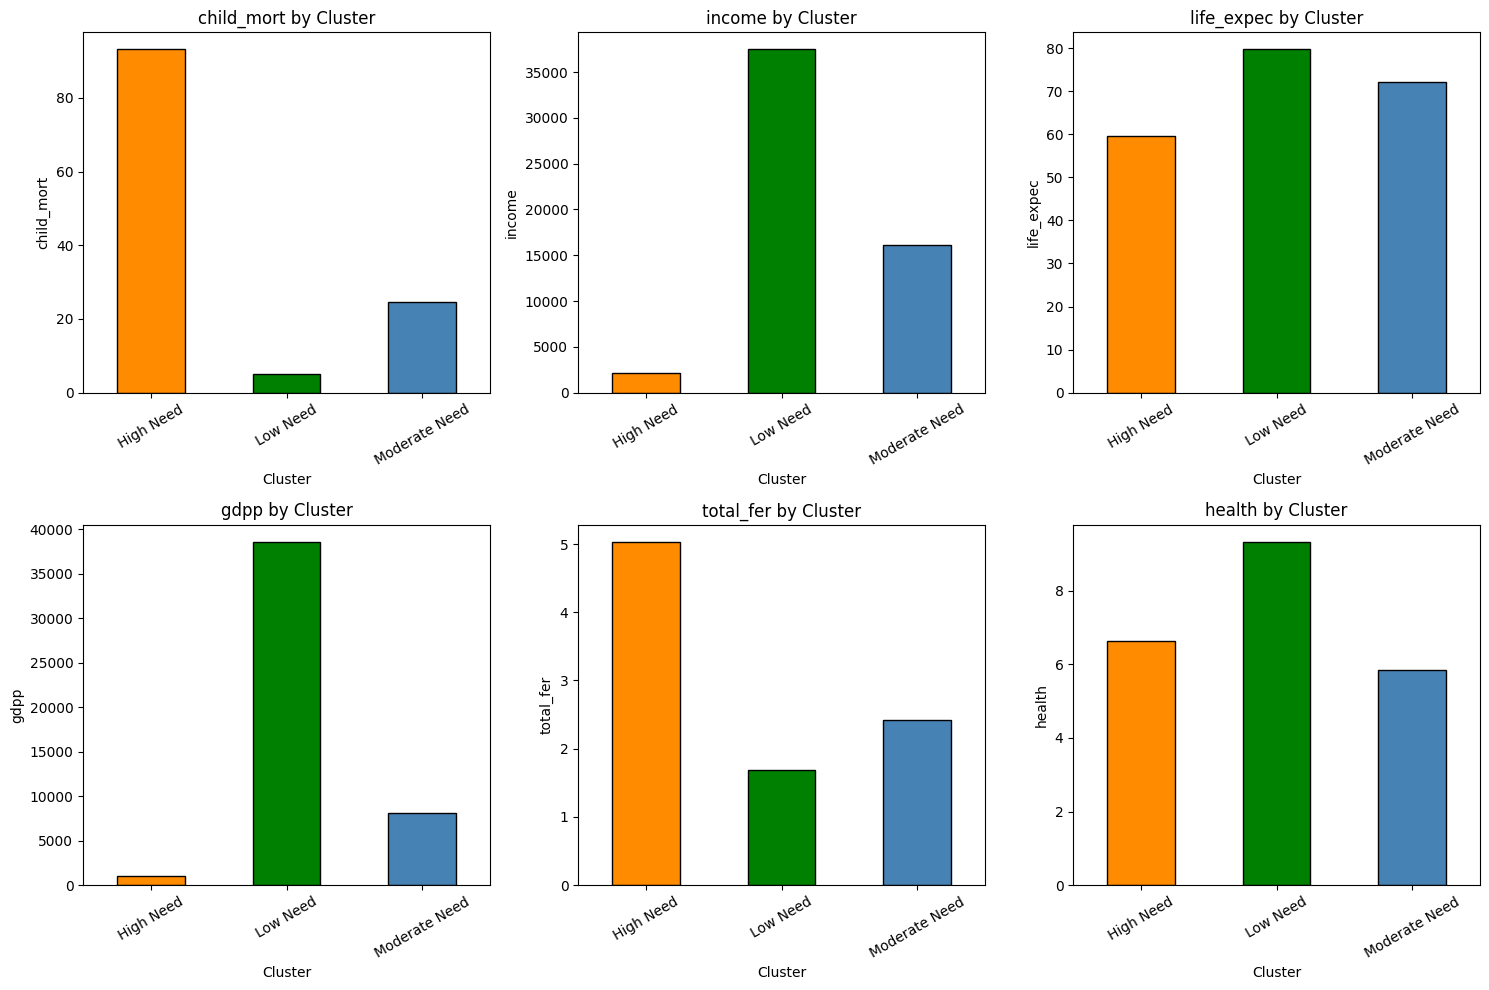

In [41]:
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer', 'health']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    cluster_means = df_eng.groupby('cluster_label')[col].mean()
    cluster_means.plot(kind='bar', ax=axes[i], color=['darkorange', 'green', 'steelblue'], edgecolor='black')
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations:**

- `child_mort`: High Need countries have drastically higher child mortality compared to the other two groups, confirming the critical condition of these countries.
- `income` and `gdpp`: Low Need countries have income and gdpp several times higher than Moderate Need and High Need countries, showing a massive economic gap.
- `life_expec`: High Need countries have the lowest life expectancy around 59 years, while Low Need countries average close to 80 years.
- `total_fer`: High Need countries have the highest fertility rate (5.03), nearly 3x that of Low Need countries (1.69).
- `health`: Low Need countries spend the most on health as a percentage of gdpp, while High Need countries spend less despite having the worst health outcomes.

These bar plots confirm that the three clusters are meaningfully separated across all key socioeconomic indicators.

In [42]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# K-Means scores
kmeans_sil = silhouette_score(X_scaled, df_eng['cluster'])
kmeans_db = davies_bouldin_score(X_scaled, df_eng['cluster'])

# DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)
agg_db = davies_bouldin_score(X_scaled, agg_labels)

print(f"K-Means - Silhouette: {kmeans_sil:.3f}, Davies-Bouldin: {kmeans_db:.3f}")
print(f"DBSCAN - Clusters found: {n_clusters_dbscan}, Noise points: {n_noise}")
print(f"Agglomerative - Silhouette: {agg_sil:.3f}, Davies-Bouldin: {agg_db:.3f}")

K-Means - Silhouette: 0.276, Davies-Bouldin: 1.257
DBSCAN - Clusters found: 1, Noise points: 16
Agglomerative - Silhouette: 0.279, Davies-Bouldin: 1.199


**Algorithm Comparison:**

- DBSCAN failed to find meaningful clusters, identifying only 1 cluster and 16 noise points. This is because the dataset lacks clear density-based boundaries, making DBSCAN unsuitable here.
- Agglomerative Clustering performs slightly better than K-Means on both silhouette score (0.279 vs 0.276) and Davies-Bouldin index (1.199 vs 1.257).
- K-Means is retained as the final clustering algorithm due to its interpretability, scalability, and the negligible performance difference with Agglomerative Clustering.
- A lower Davies-Bouldin score indicates better cluster separation. Both K-Means and Agglomerative perform comparably on this metric.

## Section 8 - Classification

In this section we use the cluster labels generated by K-Means as the target variable and train multiple classification models to predict which cluster a country belongs to based on its socioeconomic features. We compare models using cross-validation, then evaluate the best model in detail.

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

X_clf = X_scaled.copy()
y_clf = df_eng['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'KNN': KNeighborsClassifier()
}

print("5-Fold Cross Validation Results:")
print("-" * 40)
for name, model in models.items():
    acc_scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='f1_weighted')
    print(f"{name}:")
    print(f"  Accuracy  - Mean={acc_scores.mean():.3f}, Std={acc_scores.std():.3f}")
    print(f"  F1 Weighted - Mean={f1_scores.mean():.3f}, Std={f1_scores.std():.3f}")

5-Fold Cross Validation Results:
----------------------------------------
Random Forest:
  Accuracy  - Mean=0.929, Std=0.048
  F1 Weighted - Mean=0.928, Std=0.048
XGBoost:
  Accuracy  - Mean=0.899, Std=0.060
  F1 Weighted - Mean=0.898, Std=0.060
KNN:
  Accuracy  - Mean=0.922, Std=0.030
  F1 Weighted - Mean=0.922, Std=0.031


**5-Fold Cross Validation Results:**

- Random Forest achieved the highest mean accuracy (92.9%) and weighted F1 score (92.8%), with matching std of 0.048 across both metrics.
- KNN performed close second with 92.2% accuracy and 92.2% weighted F1, and the lowest std of 0.030 making it the most consistent model.
- XGBoost achieved 89.9% accuracy and 89.8% weighted F1 with the highest std of 0.060, showing slightly more variance across folds.
- The near-identical accuracy and weighted F1 scores across all models confirm that class imbalance is not significantly affecting model performance.

Random Forest is selected as the best model based on highest mean accuracy and weighted F1 score. We now evaluate it in detail on the test set.

Classification Report:
               precision    recall  f1-score   support

    High Need       1.00      0.89      0.94         9
     Low Need       0.94      0.94      0.94        17
Moderate Need       0.89      1.00      0.94         8

     accuracy                           0.94        34
    macro avg       0.94      0.94      0.94        34
 weighted avg       0.94      0.94      0.94        34



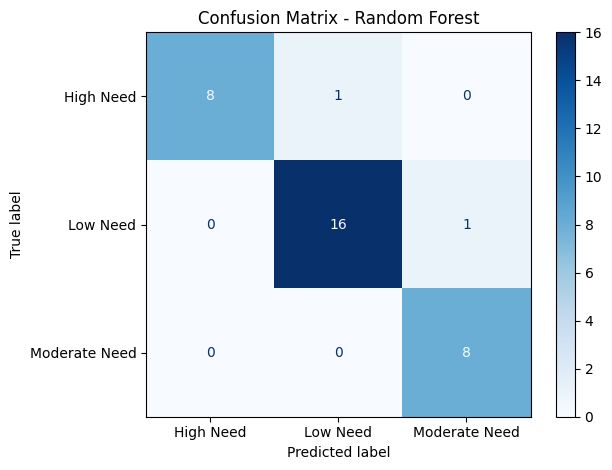

In [44]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['High Need', 'Low Need', 'Moderate Need']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High Need', 'Low Need', 'Moderate Need'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

### Feature Importance Report

Understanding feature importance helps us identify which socioeconomic indicators are most influential in classifying countries into their respective 'Need' clusters. This report will visualize the contribution of each feature to the Random Forest model's predictive power.

Top 10 Feature Importances:
                      Feature  Importance
7   mortality_fertility_index    0.190835
9              log_child_mort    0.178106
8            health_spend_abs    0.129689
10                 log_income    0.114517
5            health_gdp_ratio    0.110515
11                   log_gdpp    0.084605
4                   total_fer    0.066353
3                  life_expec    0.045966
12              log_inflation    0.025749
6               trade_balance    0.016326


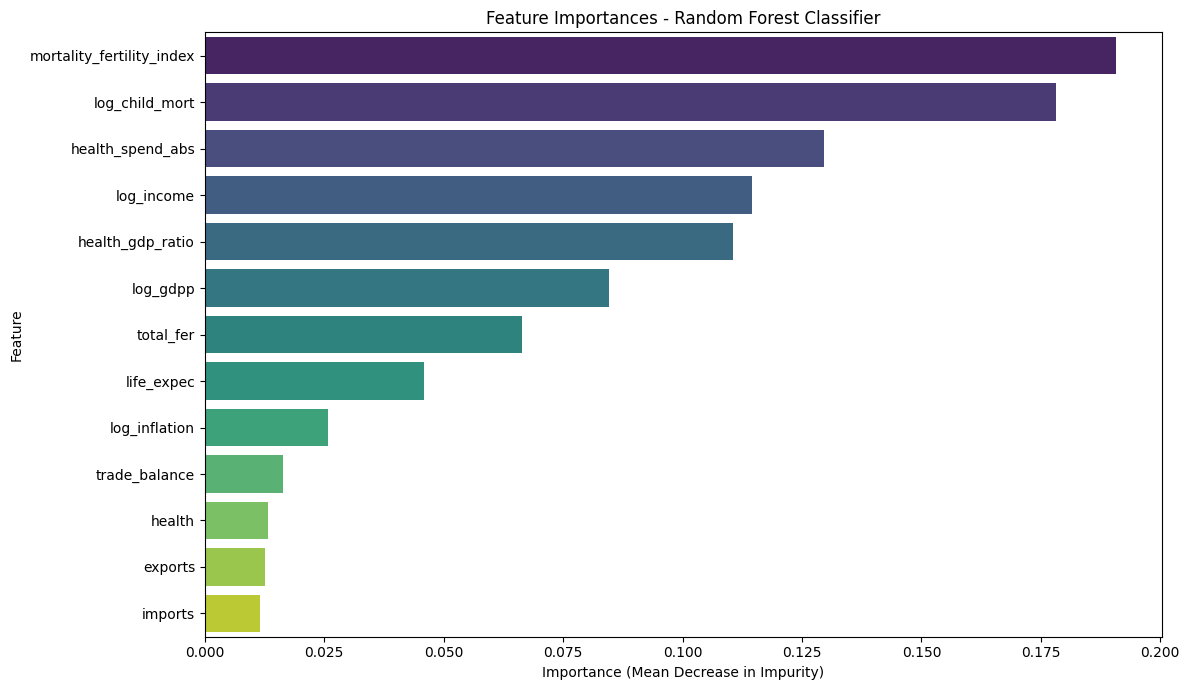

In [45]:
feature_importances = best_model.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_clf.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
print(features_df.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Feature Importances - Random Forest Classifier')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observations from Feature Importance:**

- The feature importance plot clearly highlights the most influential factors driving our model's classifications, which are largely the **engineered and log-transformed features**.
- Specifically, the **`mortality_fertility_index`** (a combination of child mortality and total fertility) stands out as the single most important feature, demonstrating its powerful ability to capture a country's overall health and developmental stress.
- **`log_child_mort`**, **`health_spend_abs`** (absolute health spending), **`log_income`**, and **`health_gdp_ratio`** are also highly significant indicators.
- While original features like `life_expec` and `total_fer` still contribute, their log-transformed counterparts and engineered combinations have taken precedence, reinforcing the value of our feature engineering step.
- This report confirms that these carefully crafted and transformed socioeconomic factors are crucial for distinguishing between 'High Need', 'Moderate Need', and 'Low Need' countries, aligning with our intuition about development indicators.

## Section 9 - Conclusion

This project was all about figuring out which countries are most in need of help. We looked at different things about countries, like how healthy their kids are, how much money people make, and how long people live. After crunching all the numbers, we found three main groups of countries:

### What Each Country Group Means

*   **'High Need' Countries:** These countries are really struggling. They have a lot of kids not making it, people don't earn much, and life expectancy is low. They're facing big challenges and need urgent support.

*   **'Moderate Need' Countries:** This group is somewhere in the middle. They're doing better than the 'High Need' countries but still have some way to go. They might need ongoing help to keep improving.

*   **'Low Need' Countries:** These are the wealthy, developed countries. Kids are healthy, people earn a lot, and they live long lives. They're usually the ones who give aid to others.

### What Helps Us Tell the Groups Apart

When we looked at what made these groups different, a few things really stood out:

1.  **Kids' Health and Birth Rate (mortality_fertility_index):** This was the biggest indicator. Countries where many children don't survive and where women have many children often need more help.
2.  **Child Mortality (log_child_mort):** How many children die young is a strong sign of a country's health situation.
3.  **Money Spent on Health (health_spend_abs):** The actual amount a country invests in health matters a lot.
4.  **Income (log_income):** How much people earn is a key measure of a country's wealth.
5.  **Health Spending vs. GDP (health_gdp_ratio):** This shows how efficiently a country uses its wealth for health, which is also important.

These findings show that things like health, wealth, and birth rates are super important for understanding a country's situation and figuring out who needs help the most.

## Section 9 - Countries List Per Cluster

In [46]:
print(" High Need Countries:")
print(df_eng[df_eng['cluster_label'] == 'High Need']['country'].tolist())
print("\n Moderate Need Countries:")
print(df_eng[df_eng['cluster_label'] == 'Moderate Need']['country'].tolist())
print("\n Low Need Countries:")
print(df_eng[df_eng['cluster_label'] == 'Low Need']['country'].tolist())

 High Need Countries:
['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', "Cote d'Ivoire", 'Eritrea', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Micronesia, Fed. Sts.', 'Mozambique', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Sudan', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']

 Moderate Need Countries:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Congo, Rep.', 'Costa Rica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Fiji', 'Gabon', 'Georgi